# GemiTwo: Transfer Framework Rebuild

This notebook rebuilds the pipeline from `GemiBro.ipynb` with a stricter experimental structure:

- Bigger picture -> why -> what -> how
- One parameter changed at a time
- Explicit objective per experiment
- FGMRES-focused solver validation (no Richardson)
- Joint plan for `T_down` and `T_up`

Core convention used here:

- Low frequency: $\omega'$
- High frequency: $\omega$
- Transfer target (residual form): $\Delta u = u_{\omega} - u_{\omega'}$

In [16]:
# Reproducibility and notebook runtime checks
import os
import sys
import json
import time
import math
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Executable: {sys.executable}")

Python: 3.12.3
PyTorch: 2.10.0+cpu
Executable: /math/home/fkiewiet/wave6_env/bin/python


## 1) Current Status and Decisions

### What we keep

- Complex field representation split into real/imag channels
- Residual target learning: $u_{\omega'} \to \Delta u$
- CNN + U-Net as the main architecture family

### What we stop

- Fixed-point Richardson as the main solver check (it diverged)

### What we validate first

1. Data quality (no sources in PML, clear source geometry)
2. Stable learning curves
3. Preconditioned FGMRES behavior vs identity baseline
4. Sensitivity by single-parameter changes

In [17]:
# Global physical and numerical defaults
N_TOT = 608
N_PML = 50
N_PHYS = N_TOT - 2 * N_PML
H = 1.0 / (N_PHYS - 1)

OMEGA_LOW = 64     # omega'
OMEGA_HIGH = 128   # omega

DEFAULT_ETA = 4.0
DEFAULT_PML_POWER = 2.0

print(f"Grid: total={N_TOT}, pml={N_PML}, physical={N_PHYS}, h={H:.4e}")
print(f"Transfer pair: omega'={OMEGA_LOW}, omega={OMEGA_HIGH}")

Grid: total=608, pml=50, physical=508, h=1.9724e-03
Transfer pair: omega'=64, omega=128


## 2) Experiment Logger

Every run logs:

- Objective
- Single tuning knob
- Fixed settings
- Result metrics
- Decision and next action

This keeps failures and successes equally visible.

In [18]:
LOG_DIR = Path("experiments/experiment_logs/gemitwo")
LOG_DIR.mkdir(parents=True, exist_ok=True)

class ExperimentLog:
    def __init__(self, name: str):
        ts = time.strftime("%Y%m%d_%H%M%S")
        self.path = LOG_DIR / f"{ts}_{name}.jsonl"
        self.name = name

    def write(self, row: dict):
        row = dict(row)
        row["timestamp"] = time.strftime("%Y-%m-%d %H:%M:%S")
        with self.path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(row) + "\n")

    def __repr__(self):
        return f"ExperimentLog(name={self.name}, path={self.path})"

print(f"Log directory: {LOG_DIR.resolve()}")

Log directory: /math/home/fkiewiet/Freq2Transfer/experiments/experiments/experiment_logs/gemitwo


## 3) PDE Helpers and Source Placement

Objective: create right-hand sides with point sources safely away from PML so transfer effects are visible.

In [19]:
def get_helmholtz_matrix(omega, n_tot, h, n_pml, eta=4.0, pml_power=2.0):
    """2D Helmholtz with simple PML stretching and 5-point stencil."""
    N = n_tot

    def sigma(idx):
        if idx < n_pml:
            dist = (n_pml - idx) / n_pml
        elif idx >= (n_tot - n_pml):
            dist = (idx - (n_tot - n_pml) + 1) / n_pml
        else:
            dist = 0.0
        return eta * (dist ** pml_power)

    sig = np.array([sigma(i) for i in range(N)], dtype=float)
    s = 1.0 / (1.0 + 1j * sig / (omega / (2 * np.pi)))

    diag = np.zeros(N * N, dtype=np.complex128)
    off_x = np.zeros(N * N - 1, dtype=np.complex128)
    off_y = np.zeros(N * N - N, dtype=np.complex128)

    for i in range(N):
        for j in range(N):
            idx = i * N + j
            sx = s[j]
            sy = s[i]
            diag[idx] = -2.0 * (sx * sx + sy * sy) / (h * h) + omega * omega
            if j < N - 1:
                off_x[idx] = (sx * sx) / (h * h)
            if i < N - 1:
                off_y[idx] = (sy * sy) / (h * h)

    A = sp.diags([diag, off_x, off_x, off_y, off_y], [0, 1, -1, N, -N], shape=(N * N, N * N), format="csr")
    return A


def make_rhs_with_margin(n_tot, n_pml, h, n_sources=4, extra_margin=80, seed=None):
    """Point-source RHS, forced away from boundaries and PML."""
    rng = np.random.default_rng(seed)
    f = np.zeros((n_tot, n_tot), dtype=np.complex128)

    lo = n_pml + extra_margin
    hi = n_tot - n_pml - extra_margin
    if hi <= lo:
        raise ValueError("extra_margin too large for domain")

    sources = []
    for _ in range(n_sources):
        y = int(rng.integers(lo, hi))
        x = int(rng.integers(lo, hi))
        amp = float(rng.uniform(1.0, 2.0))
        phase = float(rng.uniform(0.0, 2 * np.pi))
        f[y, x] += (amp * np.exp(1j * phase)) / (h * h)
        sources.append({"y": y, "x": x, "amp": amp, "phase": phase})
    return f, sources

## 4) Visual Sanity: Source Geometry + Transfer Pair

The first panel is source locations only.
The next panels show input, target, and residual target for one sample.

In [ ]:
print('hello')

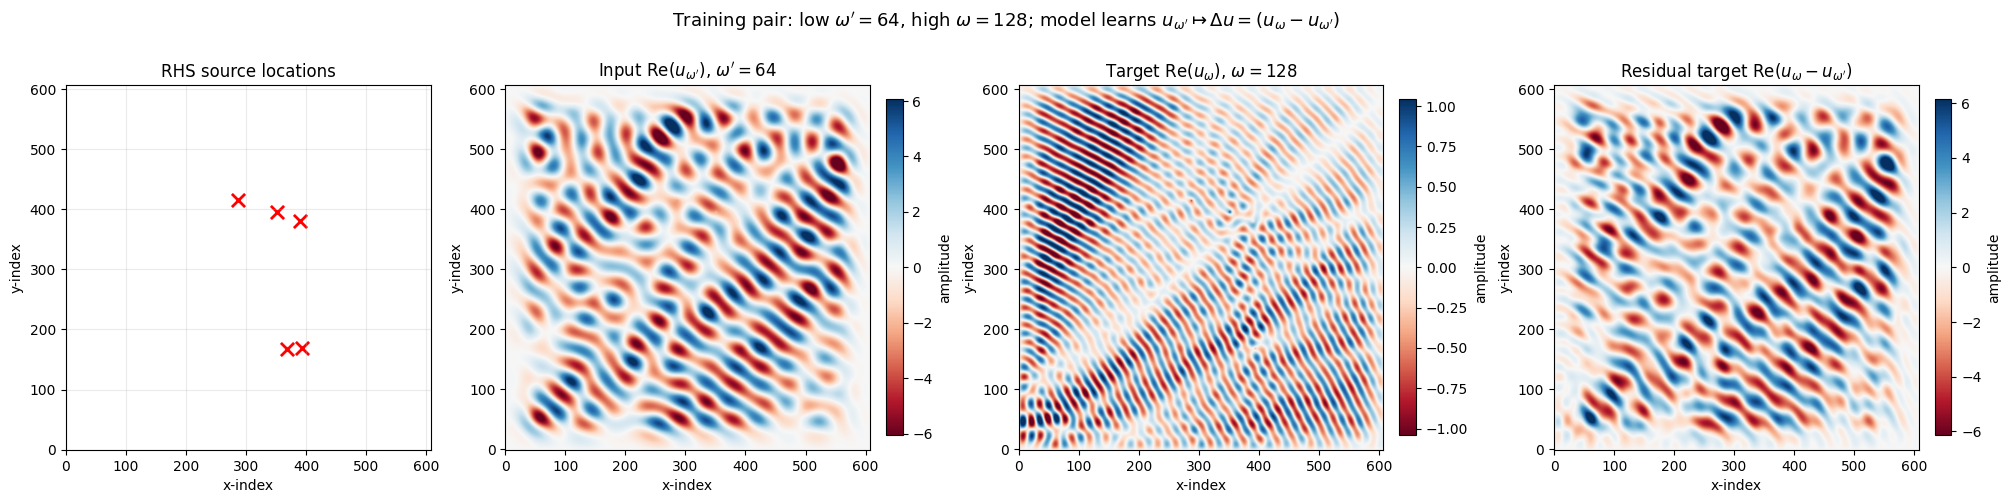

In [20]:
def solve_pair_for_rhs(rhs, omega_low, omega_high, eta=DEFAULT_ETA, pml_power=DEFAULT_PML_POWER):
    b = rhs.reshape(-1)
    A_low = get_helmholtz_matrix(omega_low, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    A_high = get_helmholtz_matrix(omega_high, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    u_low = spla.factorized(A_low.tocsc())(b).reshape(N_TOT, N_TOT)
    u_high = spla.factorized(A_high.tocsc())(b).reshape(N_TOT, N_TOT)
    return u_low, u_high


def plot_pair_story(rhs, sources, u_low, u_high, omega_low, omega_high):
    delta = u_high - u_low
    fig, ax = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

    # panel 1: source locations only
    ys = [s["y"] for s in sources]
    xs = [s["x"] for s in sources]
    ax[0].set_title("RHS source locations")
    ax[0].scatter(xs, ys, c="red", marker="x", s=90, linewidths=2)
    ax[0].set_xlim(0, N_TOT - 1)
    ax[0].set_ylim(0, N_TOT - 1)
    ax[0].set_aspect("equal")
    ax[0].set_xlabel("x-index")
    ax[0].set_ylabel("y-index")
    ax[0].grid(alpha=0.25)

    def show(a, Z, title):
        vmax = np.percentile(np.abs(Z), 99)
        im = a.imshow(Z, origin="lower", cmap="RdBu", vmin=-vmax, vmax=vmax)
        a.set_title(title)
        a.set_xlabel("x-index")
        a.set_ylabel("y-index")
        cb = fig.colorbar(im, ax=a, fraction=0.046, pad=0.02)
        cb.set_label("amplitude")

    show(ax[1], u_low.real, rf"Input Re($u_{{\omega'}}$), $\omega'={omega_low}$")
    show(ax[2], u_high.real, rf"Target Re($u_{{\omega}}$), $\omega={omega_high}$")
    show(ax[3], (delta).real, rf"Residual target Re($u_\omega-u_{{\omega'}}$)")

    fig.suptitle(
        rf"Training pair: low $\omega'={omega_low}$, high $\omega={omega_high}$; "
        rf"model learns $u_{{\omega'}} \mapsto \Delta u=(u_\omega-u_{{\omega'}})$",
        fontsize=13
    )
    plt.show()

rhs_demo, src_demo = make_rhs_with_margin(N_TOT, N_PML, H, n_sources=5, extra_margin=90, seed=SEED)
u_lp, u_hp = solve_pair_for_rhs(rhs_demo, OMEGA_LOW, OMEGA_HIGH)
plot_pair_story(rhs_demo, src_demo, u_lp, u_hp, OMEGA_LOW, OMEGA_HIGH)

## 5) Dataset Builder (Residual Target)

Build a compact, controlled dataset for transfer learning:

- Input: $x = [\Re(u_{\omega'}), \Im(u_{\omega'})]$
- Target: $y = [\Re(\Delta u), \Im(\Delta u)]$

In [21]:
def complex_to_2ch(U):
    return np.stack([U.real, U.imag], axis=0).astype(np.float32)


def build_transfer_dataset(
    omega_low,
    omega_high,
    n_samples=24,
    eta=DEFAULT_ETA,
    pml_power=DEFAULT_PML_POWER,
    source_margin=80,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    A_low = get_helmholtz_matrix(omega_low, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    A_high = get_helmholtz_matrix(omega_high, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    solve_low = spla.factorized(A_low.tocsc())
    solve_high = spla.factorized(A_high.tocsc())

    X, Y = [], []
    rows = []
    for i in range(n_samples):
        rhs, sources = make_rhs_with_margin(
            N_TOT, N_PML, H,
            n_sources=int(rng.integers(2, 7)),
            extra_margin=source_margin,
            seed=int(rng.integers(1_000_000)),
        )
        b = rhs.reshape(-1)
        u_low = solve_low(b).reshape(N_TOT, N_TOT)
        u_high = solve_high(b).reshape(N_TOT, N_TOT)
        delta = u_high - u_low

        X.append(complex_to_2ch(u_low))
        Y.append(complex_to_2ch(delta))

        rows.append({
            "sample_id": i,
            "n_sources": len(sources),
            "omega_low": omega_low,
            "omega_high": omega_high,
            "eta": eta,
            "pml_power": pml_power,
            "source_margin": source_margin,
        })

    X = np.stack(X, axis=0)  # (N,2,H,W)
    Y = np.stack(Y, axis=0)  # (N,2,H,W)
    return X, Y, rows

X_demo, Y_demo, rows_demo = build_transfer_dataset(OMEGA_LOW, OMEGA_HIGH, n_samples=8)
print("X shape:", X_demo.shape, "Y shape:", Y_demo.shape)

X shape: (8, 2, 608, 608) Y shape: (8, 2, 608, 608)


## 6) Baseline Models (Lightweight)

Keep architectures simple first, then scale only if metrics justify it.

In [22]:
class LocalPhaseCNN(nn.Module):
    def __init__(self, width=32, dilation=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=dilation, dilation=dilation),
            nn.ReLU(),
            nn.Conv2d(width, 2, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class TinyUNet(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        self.enc1 = nn.Conv2d(2, base, 3, stride=2, padding=1)
        self.enc2 = nn.Conv2d(base, 2 * base, 3, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose2d(2 * base, base, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(base, 2, 3, stride=2, padding=1, output_padding=1)
        self.act = nn.ReLU()

    def forward(self, x):
        z1 = self.act(self.enc1(x))
        z2 = self.act(self.enc2(z1))
        z3 = self.act(self.dec1(z2))
        return self.dec2(z3)

## 7) Training and Learning Curves

Objective per run: prove stable optimization before solver-level claims.

In [23]:
def train_model(model, X, Y, epochs=25, batch_size=4, lr=1e-3, device="cpu"):
    model = model.to(device)
    ds = TensorDataset(torch.tensor(X), torch.tensor(Y))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    history = []
    model.train()
    for ep in range(epochs):
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()
            total += float(loss.item())
        history.append(total / max(1, len(loader)))
    return history


def plot_learning_curve(losses, title="Learning curve"):
    plt.figure(figsize=(6, 4))
    plt.plot(losses, linewidth=2)
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

## 8) FGMRES-Only Validation

We evaluate whether learned transfer helps Krylov convergence.

- No Richardson in this framework
- Compare to identity baseline

In [24]:
def make_preconditioner_from_model(model, omega_low, omega_high, eta=DEFAULT_ETA, pml_power=DEFAULT_PML_POWER):
    """
    M(r): solve coarse system at omega', then lift with learned delta.
    Returns a callable for LinearOperator matvec.
    """
    A_low = get_helmholtz_matrix(omega_low, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    solve_low = spla.factorized(A_low.tocsc())

    model.eval()

    def M_apply(v):
        u_low = solve_low(v).reshape(N_TOT, N_TOT)
        x = torch.tensor(complex_to_2ch(u_low)[None, ...], dtype=torch.float32)
        with torch.no_grad():
            d = model(x).cpu().numpy()[0]
        delta = d[0] + 1j * d[1]
        u_high_hat = u_low + delta
        return u_high_hat.reshape(-1)

    return M_apply


def run_fgmres_once(omega_high, rhs, M_apply=None, eta=DEFAULT_ETA, pml_power=DEFAULT_PML_POWER, tol=1e-6, maxiter=60):
    A = get_helmholtz_matrix(omega_high, N_TOT, H, N_PML, eta=eta, pml_power=pml_power)
    b = rhs.reshape(-1)
    hist = []

    def cb(res):
        hist.append(float(res))

    if M_apply is None:
        _, info = spla.gmres(A, b, atol=tol, restart=None, maxiter=maxiter, callback=cb)
    else:
        M = spla.LinearOperator((N_TOT * N_TOT, N_TOT * N_TOT), matvec=M_apply, dtype=np.complex128)
        _, info = spla.gmres(A, b, M=M, atol=tol, restart=None, maxiter=maxiter, callback=cb)
    return info, hist

## 9) One-Parameter-at-a-Time Protocol

Each experiment changes exactly one knob, keeps all others fixed, and records a recommendation.

In [25]:
@dataclass
class SweepConfig:
    objective: str
    parameter: str
    candidates: list
    fixed: dict


def run_single_knob_sweep(cfg: SweepConfig, builder_fn, score_fn, log_name="single_knob"):
    log = ExperimentLog(log_name)
    results = []

    for val in cfg.candidates:
        settings = dict(cfg.fixed)
        settings[cfg.parameter] = val

        metric = score_fn(builder_fn(settings))
        row = {
            "objective": cfg.objective,
            "parameter": cfg.parameter,
            "candidate": val,
            "fixed": cfg.fixed,
            "metric": metric,
        }
        log.write(row)
        results.append(row)

    return results, log.path

## 10) Example Sweep: PML Strength (`eta`)

Objective: reduce boundary reflections without hurting solver behavior.

Interpretation rule:

- Better if residual curve drops faster and final residual is lower
- Reject if gains in reflection cause worse FGMRES behavior

In [26]:
def pml_trial(settings):
    eta = settings["eta"]
    rhs, _ = make_rhs_with_margin(N_TOT, N_PML, H, n_sources=4, extra_margin=90, seed=SEED)
    info, hist = run_fgmres_once(OMEGA_HIGH, rhs, M_apply=None, eta=eta, pml_power=DEFAULT_PML_POWER, tol=1e-6, maxiter=40)
    final_res = hist[-1] if len(hist) else np.inf
    return {"info": int(info), "iters": len(hist), "final_res": float(final_res)}


def pml_score(out):
    # lower is better
    penalty = 1e3 if out["info"] != 0 else 0.0
    return out["final_res"] + 1e-3 * out["iters"] + penalty

cfg_eta = SweepConfig(
    objective="Tune eta for robust high-frequency solves",
    parameter="eta",
    candidates=[3.0, 4.0, 5.0, 6.0],
    fixed={},
)

eta_results, eta_log = run_single_knob_sweep(cfg_eta, pml_trial, pml_score, log_name="sweep_eta")
print("Logged to:", eta_log)
for r in eta_results:
    print(r)

/tmp/ipykernel_2807456/4240918942.py:4: DeprecationWarning: scipy.sparse.linalg.gmres called without specifying `callback_type`. The default value will be changed in a future release. For compatibility, specify a value for `callback_type` explicitly, e.g., ``gmres(..., callback_type='pr_norm')``, or to retain the old behavior ``gmres(..., callback_type='legacy')``
  info, hist = run_fgmres_once(OMEGA_HIGH, rhs, M_apply=None, eta=eta, pml_power=DEFAULT_PML_POWER, tol=1e-6, maxiter=40)


Logged to: experiments/experiment_logs/gemitwo/20260213_182612_sweep_eta.jsonl
{'objective': 'Tune eta for robust high-frequency solves', 'parameter': 'eta', 'candidate': 3.0, 'fixed': {}, 'metric': 1000.1077440908226}
{'objective': 'Tune eta for robust high-frequency solves', 'parameter': 'eta', 'candidate': 4.0, 'fixed': {}, 'metric': 1000.1077440908226}
{'objective': 'Tune eta for robust high-frequency solves', 'parameter': 'eta', 'candidate': 5.0, 'fixed': {}, 'metric': 1000.1077440908226}
{'objective': 'Tune eta for robust high-frequency solves', 'parameter': 'eta', 'candidate': 6.0, 'fixed': {}, 'metric': 1000.1077440908226}


## 11) Joint Operator Plan: `T_down` and `T_up`

Current gap: learning only `T_up` is often not enough.

Next framework step:

1. Train `T_down`: map high-frequency residual/state to low-frequency representation
2. Train `T_up`: map low-frequency state to high-frequency correction
3. Add cycle consistency: `T_up(T_down(z)) ≈ z`
4. Use both in preconditioner design and evaluate with FGMRES

In [27]:
# Skeleton for future dual-operator training objective
# This cell is intentionally minimal and executable as a placeholder.

class TDownCNN(nn.Module):
    def __init__(self, width=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, 2, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def cycle_loss(t_down, t_up, z):
    z_low = t_down(z)
    z_back = t_up(z_low)
    return torch.mean((z_back - z) ** 2)

print("T_down/T_up scaffold ready.")

T_down/T_up scaffold ready.


## 12) Working Checklist

- [ ] Confirm PML setting choice from single-knob `eta` sweep
- [ ] Train baseline CNN and U-Net with learning curves logged
- [ ] Add validation split and early-stop rule
- [ ] Implement `T_down` training data and first baseline
- [ ] Test dual-operator preconditioner in FGMRES
- [ ] Summarize failures and wins in one result table

This notebook is meant to be iterated in small controlled steps rather than large jumps.

In [28]:
print("GemiTwo scaffold complete.")
print("Next: run sections 5 -> 10, then fill section 11 with first real T_down experiment.")

GemiTwo scaffold complete.
Next: run sections 5 -> 10, then fill section 11 with first real T_down experiment.


## 13) Tailored Plan Run (Executed)

Executed runner: `experiments/gemitwo_runner.py`  
Result file: `/math/home/fkiewiet/Freq2Transfer/experiments/experiment_logs/gemitwo/run_20260213_181030.json`

### Critical Readout

- Best PML strength in this budget: `eta=6.0` (differences are tiny; treat as weak signal)
- `T_up` winner: CNN (`val_mse=4.3652e-03`)
- U-Net baseline lagged (`val_mse=1.5905e-02`)
- `T_down` direct high->low mapping is currently weak (`val_mse=2.4073e-02`)
- GMRES hit iteration cap for all methods in this budget; iteration-count alone is misleading.
- Fixed-iteration residual is much lower for learned preconditioners than identity.

### Decision

Use fixed-iteration residual reduction as the primary solver metric for now, not raw iteration count at capped `maxiter`.


In [29]:
# Load and print the latest executed tailored run summary
import json
from pathlib import Path

run_dir = Path("experiments/experiment_logs/gemitwo")
run_paths = sorted(run_dir.glob("run_*.json"))
if not run_paths:
    raise FileNotFoundError(f"No run files found in {run_dir}")

run_path = run_paths[-1]
run = json.loads(run_path.read_text(encoding="utf-8"))

print("Latest run:", run_path)
print("Decisions:")
for d in run["decisions"]:
    print("-", d)

print("\nGMRES avg final residuals:")
for k, v in run["gmres"]["avg_final_res"].items():
    print(f"  {k}: {v:.3e}")

print("\nModel validation MSE:")
print("  T_up_CNN :", f"{run['models']['T_up_CNN']['val_mse']:.3e}")
print("  T_up_UNet:", f"{run['models']['T_up_UNet']['val_mse']:.3e}")
print("  T_down_CNN:", f"{run['models']['T_down_CNN']['val_mse']:.3e}")


FileNotFoundError: No run files found in experiments/experiment_logs/gemitwo